# 05 Adavanced Models

Gradient Boosting (e.g., XGBoost or LightGBM). 
Perform light hyperparameter tuning (depth, learning rate, n_estimators). 

## Setup

In [1]:
# %pip install lightgbm
# %pip install xgboost
# %pip install catboost

import os, glob
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)
from sklearn.model_selection import ParameterSampler

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from scipy.stats import randint, uniform

pd.set_option('display.max_columns', 100)

DATA = sorted(glob.glob('../../data/cleaned_CRMLSSold*.csv'))[-1]
RESULTS = '../../results/model_results.csv'

TARGET = 'ClosePrice'
DATE = 'CloseDate'

df = pd.read_csv(DATA, parse_dates=[DATE])
print(f"loaded {DATA}  ->  {df.shape[0]:,} rows x {df.shape[1]} columns")

TEST_MONTH = (pd.read_csv(DATA, usecols=[DATE], parse_dates=[DATE])[DATE].dt.to_period("M").astype(str).max())
MAX_TRAIN_MONTHS = 11 

avail_data = (pd.read_csv(DATA, usecols=[DATE], parse_dates=[DATE])[DATE].dt.to_period("M").nunique() - 1)
TRAIN_MONTHS = min(avail_data, MAX_TRAIN_MONTHS)

RANDOM_STATE = 42 #needed for decision tree and random forest
print(f"Using {DATA}  |  test month = {TEST_MONTH}  |  train window = {TRAIN_MONTHS} months")

WEEK = 7

C:\Users\Vivian\AppData\Local\Temp\ipykernel_14248\3316842663.py:38: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA, parse_dates=[DATE])


loaded ../../data\cleaned_CRMLSSold202506_202606.csv  ->  142,750 rows x 1567 columns
Using ../../data\cleaned_CRMLSSold202506_202606.csv  |  test month = 2026-06  |  train window = 11 months


In [2]:
#split data into train/test sets

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):

      months = data[date].dt.to_period("M")
      test_p = pd.Period(test_month, freq="M")
      train_start = test_p - window 

      test = data[months == test_p]
      train = data[(months >= train_start) & (months < test_p)]
      # Error checks
      assert len(train) > 0 and len(test) > 0, "ERROR: Empty split (check params)"
      assert train[date].max() < test[date].min(), "Chronology violated"
      return train, test

train_df, test_df = chrono_split(df)

print(f"Train: {train_df.shape[0]:,} rows "f"({train_df[DATE].min().date()} --> {train_df[DATE].max().date()})")
print(f"Test:  {test_df.shape[0]:,} rows "f"({test_df[DATE].min().date()} --> {test_df[DATE].max().date()})")

Train: 118,247 rows (2025-07-01 --> 2026-05-31)
Test:  12,837 rows (2026-06-01 --> 2026-06-30)


In [3]:
# trim to train 1/99 bounds
def trim_to_train_bounds(train, test, target=TARGET, low=0.01, high=0.99):
    lo, hi = train[target].quantile(low), train[target].quantile(high)
    return (train[train[target].between(lo, hi)].copy(),
            test[test[target].between(lo, hi)].copy(), lo, hi)

test_df_full = test_df.copy()
_ntr, _nte = len(train_df), len(test_df)
train_df, test_df, TRIM_LO, TRIM_HI = trim_to_train_bounds(train_df, test_df)
print(f"Trim bounds (train 1/99): ${TRIM_LO:,.0f} - ${TRIM_HI:,.0f}")
print(f"Train: {_ntr:,} -> {len(train_df):,} | Test: {_nte:,} -> {len(test_df):,}")

Trim bounds (train 1/99): $235,000 - $6,300,000
Train: 118,247 -> 115,941 | Test: 12,837 -> 12,570


In [4]:
EXCLUDE = [
    "ListingKey",              
    "CloseDate", "CloseMonth",  

    "ClosePrice",               # target var
    "ClosePrice_log",           # target in log form
    "ClosePrice_repaired",      # metadata

    "CountyOrParish",           # one-hots from 02_preprocessing
    "PostalCode",               

    "LivingArea",               # using LivingArea_log
    "LotSizeAcres",             # using LotSizeAcres_log

    "County_Los_Angeles",       # reference
    "SchoolDistrict",
    "BedBathRatio", 
    "PropertyAge", 
    "LotToLiving_log", 
    "LotToLiving",
    "City",
    "LivingAreaPerBedroom",
    "HasGarage",
    "AmenityCount"

]

feature = [c for c in df.columns if c not in EXCLUDE and not c.startswith("District_")]
print(f"Old Feature Set: {len(feature)} features"
    f"({sum(c.startswith('Zip_') for c in feature)} ZIP, "
    f"{sum(c.startswith('City_') for c in feature)} City)")


# Checks
assert not any("ClosePrice" in c for c in feature), "Target column leaked"
assert df[feature].isna().sum().sum() == 0, "Feature matrix contains NaNs"

X_train, X_test = train_df[feature], test_df[feature]
y_train, y_test = train_df[TARGET], test_df[TARGET]

Old Feature Set: 1185 features(705 ZIP, 407 City)


In [5]:
def fit_eval(model, use_log=True, X_tr=None, X_te=None):
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te

    ytr = np.log(y_train) if use_log else y_train
    model.fit(X_tr, ytr)

    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    if use_log:
        pred_train, pred_test = np.exp(pred_train), np.exp(pred_test)

    return {
        "model": model,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
    }

In [6]:
def log_result(model_name, version, train_r2, test_r2, change_note, target_space="raw(ClosePrice)", week=5, n_features=None):
    n_features = len(feature) if n_features is None else n_features
    os.makedirs(os.path.dirname(RESULTS), exist_ok=True)
    row = pd.DataFrame([{
        "week": week, "model": model_name, "version": version,
        "target": target_space, "train_months": TRAIN_MONTHS,
        "test_month": TEST_MONTH, "n_features": n_features,
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4),
        "change_note": change_note,
    }])
    if os.path.exists(RESULTS):
        log = pd.read_csv(RESULTS)
        same = ((log["model"] == model_name) & (log["version"] == version)
                & (log["week"] == week) & (log["test_month"] == TEST_MONTH)
                & (log["train_months"] == TRAIN_MONTHS))
        log = log[~same]
        log = pd.concat([log, row], ignore_index=True)
    else:
        log = row
    log.to_csv(RESULTS, index=False)
    print(f"logged: {model_name} {version} | week {week} | n_feat {n_features} | "
            f"train R2 {train_r2:.4f} | test R2 {test_r2:.4f}")

results_log = pd.read_csv(RESULTS)
base = results_log[(results_log["model"] == "LinearRegression") &
                    (results_log["version"] == "baseline")]
assert len(base) == 1, "Missing baseline row, run 03baseline_model.ipynb first."

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lin = fit_eval(LinearRegression(), use_log=False, X_tr=X_train_s, X_te=X_test_s)
print(f"linear (raw): train R^2 = {lin['train_r2']:.4f} | test R^2 = {lin['test_r2']:.4f}")

BASELINE_R2 = float(base['test_r2'].iloc[0])
assert abs(lin['test_r2'] - BASELINE_R2) < 0.01, "04 unable to reproduce 03's result"

linear (raw): train R^2 = 0.8158 | test R^2 = 0.8152


In [7]:
order = np.argsort(train_df[DATE].to_numpy())
Xtr = train_df.iloc[order][feature].reset_index(drop=True)
ytr = train_df.iloc[order][TARGET].reset_index(drop=True)   # raw ClosePrice target

per = train_df.iloc[order][DATE].dt.to_period("M").reset_index(drop=True)
monthly_splits = []
for vm in sorted(per.unique())[-4:]: #using recent 4 months
    tr_pos = np.flatnonzero((per < vm).to_numpy())
    va_pos = np.flatnonzero((per == vm).to_numpy())
    monthly_splits.append((tr_pos, va_pos))

## GB.A LightGBM

In [8]:
gb_a = fit_eval(
    LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63,
                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])

print(f"LightGBM A (raw): train {gb_a['train_r2']:.4f} | test {gb_a['test_r2']:.4f} "
      f"| gap {gb_a['train_r2'] - gb_a['test_r2']:.4f}")
print(f"(baseline = {BASELINE_R2:.4f} | RF.B to beat = 0.8699)")

log_result("LightGBM", "A", gb_a["train_r2"], gb_a["test_r2"],
           "defaults: 400 trees, lr=0.05, num_leaves=63, raw target", week=WEEK)

# running GB.A on full non trimmed June

X_test_full = test_df_full[feature]
gb_pred_full = gb_a["model"].predict(X_test_full)

print("\n")
print("LightGBM A raw, dollar R^2:")
print(f"  contract (train-1/99 trimmed test): {gb_a['test_r2']:.4f}  [n={len(test_df):,}]")
print(f"  full untrimmed test (stricter):     {r2_score(test_df_full[TARGET], gb_pred_full):.4f}  [n={len(test_df_full):,}]")

LightGBM A (raw): train 0.9220 | test 0.8889 | gap 0.0331
(baseline = 0.8152 | RF.B to beat = 0.8699)
logged: LightGBM A | week 7 | n_feat 1185 | train R2 0.9220 | test R2 0.8889


LightGBM A raw, dollar R^2:
  contract (train-1/99 trimmed test): 0.8889  [n=12,570]
  full untrimmed test (stricter):     0.5811  [n=12,837]


### Interpret:

- between the trimmed and untrimmed set, there's a 0.3 spread
- currently the best performing model on the trimmed (1/99) train to test set
- however when we actually see the untrimmed (which includes the luxury), its 0.58 which characterizes the full market and is technically more realistic

## GB.B LightGBM tuned

Tunes with recent 4 months

In [9]:
gb_grid = {"n_estimators":  [300, 600, 900, 1200],
    "learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
    "num_leaves":    [31, 63, 127],
}

gb_search = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    gb_grid, cv=monthly_splits, scoring="r2", n_jobs=-1, verbose=1)
gb_search.fit(Xtr, ytr)

print("best params:", gb_search.best_params_, "| best monthly CV R^2 (raw):", round(gb_search.best_score_, 4))


gb_b = fit_eval(
    LGBMRegressor(**gb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
print(f"LightGBM B tuned (raw): train {gb_b['train_r2']:.4f} | test {gb_b['test_r2']:.4f} "
      f"| gap {gb_b['train_r2'] - gb_b['test_r2']:.4f}")

log_result("LightGBM", "B-tuned", gb_b["train_r2"], gb_b["test_r2"],
           f"month-blocked(4) tuned, best={gb_search.best_params_}, raw target", week=WEEK)

Fitting 4 folds for each of 60 candidates, totalling 240 fits
best params: {'learning_rate': 0.15, 'n_estimators': 1200, 'num_leaves': 31} | best monthly CV R^2 (raw): 0.8948
LightGBM B tuned (raw): train 0.9501 | test 0.8970 | gap 0.0531
logged: LightGBM B-tuned | week 7 | n_feat 1185 | train R2 0.9501 | test R2 0.8970


### Interpret
- tuning on the trimmed set has yielded the best results out of all the models
- the parameters chosen by the grid are even higher and a wider grid could potentially score even higher
    - continued expanding the tuning parameters:
        - n_estimators: 
            - continued to grow at each new one, but the increase is exteremely small now
            - and the larger, the runtime exceeds 5 minutes, I'm making the decision to stop it here
        - learning_rate:
            - optimal stopped at 0.15
        - num_leaves:
            - chose the minimum value at 31, meaning simple trees are prefereed for LGBM
- tuned result: 
    - on trimed train to test (1/99) = 0.897

- RUNTIME: 10:18 minutes 

In [10]:
# running GB.B on full non trimmed June

gb_b_pred_full = gb_b["model"].predict(test_df_full[feature])
print("LightGBM B tuned, raw dollar R^2:")
print(f"  contract (trimmed): {gb_b['test_r2']:.4f}  [n={len(test_df):,}]")
print(f"  full untrimmed:     {r2_score(test_df_full[TARGET], gb_b_pred_full):.4f}  [n={len(test_df_full):,}]")

LightGBM B tuned, raw dollar R^2:
  contract (trimmed): 0.8970  [n=12,570]
  full untrimmed:     0.6048  [n=12,837]


### Interpret:

- on the untrimmed model, R^2 = 0.6048 which is the best untrimmed performance (that is accounting for the luxury right tail too)
- as it also does really well on the trimmed set, overall the model is the strongest

## GB.C XGBoost

default XGBoost

In [11]:
xgb_a = fit_eval(
    XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                 tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
print(f"XGBoost A (raw): train {xgb_a['train_r2']:.4f} | test {xgb_a['test_r2']:.4f} "
      f"| gap {xgb_a['train_r2'] - xgb_a['test_r2']:.4f}")

print("\n")
# honest number of the untrimmed test set
xgb_pred_full = xgb_a["model"].predict(test_df_full[feature])
print(f"  contract (trimmed): {xgb_a['test_r2']:.4f}  | full untrimmed: "
      f"{r2_score(test_df_full[TARGET], xgb_pred_full):.4f}")

log_result("XGBoost", "A", xgb_a["train_r2"], xgb_a["test_r2"],
           "defaults: 600 trees, lr=0.05, max_depth=6, hist, raw target", week=WEEK)

XGBoost A (raw): train 0.9015 | test 0.8676 | gap 0.0339


  contract (trimmed): 0.8676  | full untrimmed: 0.5654
logged: XGBoost A | week 7 | n_feat 1185 | train R2 0.9015 | test R2 0.8676


### Interpret

- Compared to LightGBM, the trimmed (1/99) test is stronger than this default XGBoost
- When looking at the untrimmed results of the test month, the R^2 value is 0.56 which, again the results still do not win over LightGBM especailly when characterizing the full set

## GB.D XGBoost tuned

altering the parameters

In [12]:
# xgb_grid = {
#     "n_estimators":  [300, 600, 900, 1200],
#     "learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
#     "max_depth":     [4, 5, 6, 7], #model uses depth instead
# }
# xgb_search = GridSearchCV(
#     XGBRegressor(tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
#     xgb_grid, cv=monthly_splits, scoring="r2", n_jobs=-1, verbose=1)
# xgb_search.fit(Xtr, ytr)
# print("best params:", xgb_search.best_params_, "| best monthly CV R^2 (raw):", round(xgb_search.best_score_, 4))

# xgb_b = fit_eval(
#     XGBRegressor(**xgb_search.best_params_, tree_method="hist",
#                  random_state=RANDOM_STATE, n_jobs=-1),
#     use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
# print(f"XGBoost B tuned (raw): train {xgb_b['train_r2']:.4f} | test {xgb_b['test_r2']:.4f} "
#       f"| gap {xgb_b['train_r2'] - xgb_b['test_r2']:.4f}")

# xgb_b_full = xgb_b["model"].predict(test_df_full[feature])
# print(f"  contract (trimmed): {xgb_b['test_r2']:.4f}  | full untrimmed: "
#       f"{r2_score(test_df_full[TARGET], xgb_b_full):.4f}")

# log_result("XGBoost", "B-tuned", xgb_b["train_r2"], xgb_b["test_r2"],
#            f"month-blocked(4) tuned, best={xgb_search.best_params_}, hist, raw target", week=WEEK)

### Interpret:

- run 13+ minutes to complete
- just not ideal for the size of our dataframe
- at this point it's clear to that LightGBM wins over XGBoost, already at default and at tuned (run-time length is too inefficient)

## GB.E CatBoost

Default CatBoost (Implemented post team meeting)

In [33]:

onehot_pref = ("Zip_", "City_", "County_", "District_")
structural  = [c for c in feature if not c.startswith(onehot_pref)]
cat_cols    = [c for c in ["PostalCode", "City", "CountyOrParish", "SchoolDistrict"]
               if c in df.columns]
native      = structural + cat_cols
print(f"native set: {len(structural)} structural + {len(cat_cols)} categorical "
      f"({cat_cols}) -> {len(native)} cols  (vs {len(feature)} one-hot)")

def cb_frame(frame):
    X = frame[native].copy()
    for c in cat_cols:
        X[c] = frame[c].astype("string").fillna("Unknown").astype(str)
    return X

Xtr_cb, Xte_cb, Xfull_cb = cb_frame(train_df), cb_frame(test_df), cb_frame(test_df_full)

cat_a = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6,
                              cat_features=cat_cols, max_ctr_complexity=1,
                              random_state=RANDOM_STATE, verbose=False)
cat_a.fit(Xtr_cb, y_train)

cb = {"train_r2": r2_score(y_train, cat_a.predict(Xtr_cb)),
      "test_r2":  r2_score(y_test,  cat_a.predict(Xte_cb))}
print(f"CatBoost A: train {cb['train_r2']:.4f} | test {cb['test_r2']:.4f} "
      f"| gap {cb['train_r2'] - cb['test_r2']:.4f}")
print(f"(baseline = {BASELINE_R2:.4f} | LightGBM B-tuned to beat = 0.8970)")

cb_full = r2_score(test_df_full[TARGET], cat_a.predict(Xfull_cb))
print(f"  contract (trimmed): {cb['test_r2']:.4f}  | full untrimmed: {cb_full:.4f}")

log_result("CatBoost", "A", cb["train_r2"], cb["test_r2"],
           f"native cat ({cat_cols}), 1000 trees, lr=0.05, depth=6, raw target",
           week=WEEK, n_features=len(native))

native set: 18 structural + 4 categorical (['PostalCode', 'City', 'CountyOrParish', 'SchoolDistrict']) -> 22 cols  (vs 1185 one-hot)
CatBoost A: train 0.9001 | test 0.8813 | gap 0.0188
(baseline = 0.8152 | LightGBM B-tuned to beat = 0.8970)
  contract (trimmed): 0.8813  | full untrimmed: 0.6040
logged: CatBoost A | week 7 | n_feat 22 | train R2 0.9001 | test R2 0.8813


### Interpret

- Trimmed result = 0.8813, untrimmed result is 0.604
- Performs stronger than XGBoost model, but not as strong as Light GBM
- skips over the categorial one-hots I previously set up
- runs much faster than XGBoost
- much lower overfitting than the Tuned LightGBM (which is currently the strongest model still)

## GB.F CatBoost (tuned)

- consider early stop/candidate scoring
- tuning native categoricals
- early stopping to set tree count
- training on 90% of fit not whole refit

In [27]:
# last 10% of training by date
sort_idx = np.argsort(train_df[DATE].to_numpy())
val_size = int(0.10 * len(train_df))
fit_pos, val_pos = sort_idx[:-val_size], sort_idx[-val_size:]
X_fit, X_val = Xtr_cb.iloc[fit_pos], Xtr_cb.iloc[val_pos]
y_fit, y_val = y_train.iloc[fit_pos], y_train.iloc[val_pos]

# search on a subsample of the fit set, refit the winner on full data.
SEARCH_ROWS = 30000
rs  = np.random.RandomState(RANDOM_STATE)
sub = rs.choice(len(X_fit), size=min(SEARCH_ROWS, len(X_fit)), replace=False)
X_fit_s, y_fit_s = X_fit.iloc[sub], y_fit.iloc[sub]
print(f"search on {len(X_fit_s):,} of {len(X_fit):,} fit rows | val (full, last 10% by date) {len(X_val):,} "
      f"({train_df[DATE].iloc[val_pos].dt.to_period('M').min()} -> "
      f"{train_df[DATE].iloc[val_pos].dt.to_period('M').max()})")

cat_param_dist = {"depth": randint(4, 6), "learning_rate": uniform(0.01, 0.15),
                  "l2_leaf_reg": uniform(3, 9)}
cat_candidates = list(ParameterSampler(cat_param_dist, n_iter=10, random_state=RANDOM_STATE))

cat_results = []
for i, params in enumerate(cat_candidates, 1):
    m = CatBoostRegressor(iterations=2000, cat_features=cat_cols, max_ctr_complexity=1,
                          early_stopping_rounds=50, random_state=RANDOM_STATE,
                          thread_count=-1, verbose=False, **params)
    m.fit(X_fit_s, y_fit_s, eval_set=(X_val, y_val))
    vr2 = r2_score(y_val, m.predict(X_val))
    cat_results.append((params, vr2, m.get_best_iteration()))
    print(f"  [{i:2d}/10] depth={params['depth']} lr={params['learning_rate']:.3f} "
          f"l2={params['l2_leaf_reg']:.2f} -> val R2 {vr2:.4f} (best_iter {m.get_best_iteration()})")

cat_best_params, cat_best_val_r2, cat_best_iter = max(cat_results, key=lambda r: r[1])
print(f"\nbest: {cat_best_params} | val R2 {cat_best_val_r2:.4f} | iters {cat_best_iter}")

search on 30,000 of 104,347 fit rows | val (full, last 10% by date) 11,594 (2026-05 -> 2026-05)
  [ 1/10] depth=4 lr=0.038 l2=10.17 -> val R2 0.8590 (best_iter 1999)
  [ 2/10] depth=5 lr=0.033 l2=8.39 -> val R2 0.8638 (best_iter 1992)
  [ 3/10] depth=4 lr=0.079 l2=3.90 -> val R2 0.8730 (best_iter 1995)
  [ 4/10] depth=4 lr=0.116 l2=8.41 -> val R2 0.8759 (best_iter 1989)
  [ 5/10] depth=5 lr=0.118 l2=3.51 -> val R2 0.8783 (best_iter 1667)
  [ 6/10] depth=5 lr=0.037 l2=4.91 -> val R2 0.8686 (best_iter 1997)
  [ 7/10] depth=4 lr=0.102 l2=8.56 -> val R2 0.8737 (best_iter 1999)
  [ 8/10] depth=4 lr=0.054 l2=6.89 -> val R2 0.8676 (best_iter 1999)
  [ 9/10] depth=4 lr=0.017 l2=6.60 -> val R2 0.8433 (best_iter 1999)
  [10/10] depth=5 lr=0.078 l2=6.30 -> val R2 0.8775 (best_iter 1995)

best: {'depth': 5, 'l2_leaf_reg': np.float64(3.5077042112439023), 'learning_rate': np.float64(0.1182998158400237)} | val R2 0.8783 | iters 1667


In [28]:
# refit best params on the FULL training window (search used a subsample, so this refit matters)
cat_b = CatBoostRegressor(iterations=cat_best_iter + 1, cat_features=cat_cols,
                              max_ctr_complexity=1, random_state=RANDOM_STATE,
                              thread_count=-1, verbose=False, **cat_best_params)
cat_b.fit(Xtr_cb, y_train)

cbt = {"train_r2": r2_score(y_train, cat_b.predict(Xtr_cb)),
       "test_r2":  r2_score(y_test,  cat_b.predict(Xte_cb))}
cbt_full = r2_score(test_df_full[TARGET], cat_b.predict(Xfull_cb))
print(f"CatBoost B tuned: train {cbt['train_r2']:.4f} | "
      f"test {cbt['test_r2']:.4f} | gap {cbt['train_r2'] - cbt['test_r2']:.4f}")
print(f"(baseline = {BASELINE_R2:.4f} | LightGBM B-tuned to beat = 0.8970 | CatBoost A = 0.8813)")
print(f"  contract (trimmed): {cbt['test_r2']:.4f}  | full untrimmed: {cbt_full:.4f}")

log_result("CatBoost", "B-tuned", cbt["train_r2"], cbt["test_r2"],
           f"native, randomized(depth/lr/l2), {SEARCH_ROWS}-row search + full refit, "
           f"ES@{cat_best_iter}, best={cat_best_params}", week=WEEK, n_features=len(native))

CatBoost B tuned: train 0.9211 | test 0.8936 | gap 0.0274
(baseline = 0.8152 | LightGBM B-tuned to beat = 0.8970 | CatBoost A = 0.8813)
  contract (trimmed): 0.8936  | full untrimmed: 0.6224
logged: CatBoost B-tuned | week 7 | n_feat 22 | train R2 0.9211 | test R2 0.8936


### Interpret

- best result params: depth=5, lr=0.118, l2_leaf_reg=3.51
- R^2: train R2 0.9211 | test R2 0.8936
- untrimmed (full test month) = 0.6224
- the tuned model has boosted to be nearly as strong as LightGBM (GB.B tuned) with a difference of 0.004, making them essentially the same
    - however, the gap value is nearly half of LGBM's 
- incomparison to LGBM, this model still takes much longer to process
- the search method is hitting the 2000-tree ceiling consistently, so the ceiling could be increased
- Considering the strength of the untrimmed R^2 is the best thus far, this model has a win over the LightGBM even if the trimmed values are different by a very small value.

## Comparing to all the models

In [34]:
# recalculating all the model results untrimmed for the full test month (June)

full_june = {}
Xfull_oh = test_df_full[feature]
candidates = [
    ("LightGBM|A",        "gb_a",      "dict", Xfull_oh),
    ("LightGBM|B-tuned",  "gb_b",      "dict", Xfull_oh),
    ("XGBoost|A",         "xgb_a",     "dict", Xfull_oh),
    ("CatBoost|A",        "cat_a",     "est",  Xfull_cb),
    ("CatBoost|B-tuned",  "cat_b",     "est",  Xfull_cb),

]
for key, name, kind, Xf in candidates:
    if name in globals():
        mdl = globals()[name]["model"] if kind == "dict" else globals()[name]
        full_june[key] = round(r2_score(test_df_full[TARGET], mdl.predict(Xf)), 4)
print("full-June (untrimmed) R²:", full_june)

full-June (untrimmed) R²: {'LightGBM|A': 0.5811, 'LightGBM|B-tuned': 0.6048, 'XGBoost|A': 0.5654, 'CatBoost|A': 0.604, 'CatBoost|B-tuned': 0.6224}


In [37]:
# results display

res = pd.read_csv(RESULTS)
res["gap"] = (res["train_r2"] - res["test_r2"]).round(4)
res["key"] = res["model"] + "|" + res["version"]
res["full_june_r2"] = res["key"].map(full_june)
res = res.sort_values("test_r2", ascending=False).reset_index(drop=True)
res.insert(0, "rank", res.index + 1)

cols = ["rank", "week", "model", "version", "n_features", "train_r2", "test_r2", "full_june_r2", "gap", "change_note"]
print(res[cols].to_string(index=False))

 rank  week            model             version  n_features  train_r2  test_r2  full_june_r2    gap                                                                                                                                                                                change_note
    1     7         LightGBM             B-tuned        1185    0.9501   0.8970        0.6048 0.0531                                                                                   month-blocked(4) tuned, best={'learning_rate': 0.15, 'n_estimators': 1200, 'num_leaves': 31}, raw target
    2     7         CatBoost             B-tuned          22    0.9211   0.8936        0.6224 0.0275 native, randomized(depth/lr/l2), 30000-row search + full refit, ES@1667, best={'depth': 5, 'l2_leaf_reg': np.float64(3.5077042112439023), 'learning_rate': np.float64(0.1182998158400237)}
    3     7         LightGBM                   A        1185    0.9220   0.8889        0.5811 0.0331                                    

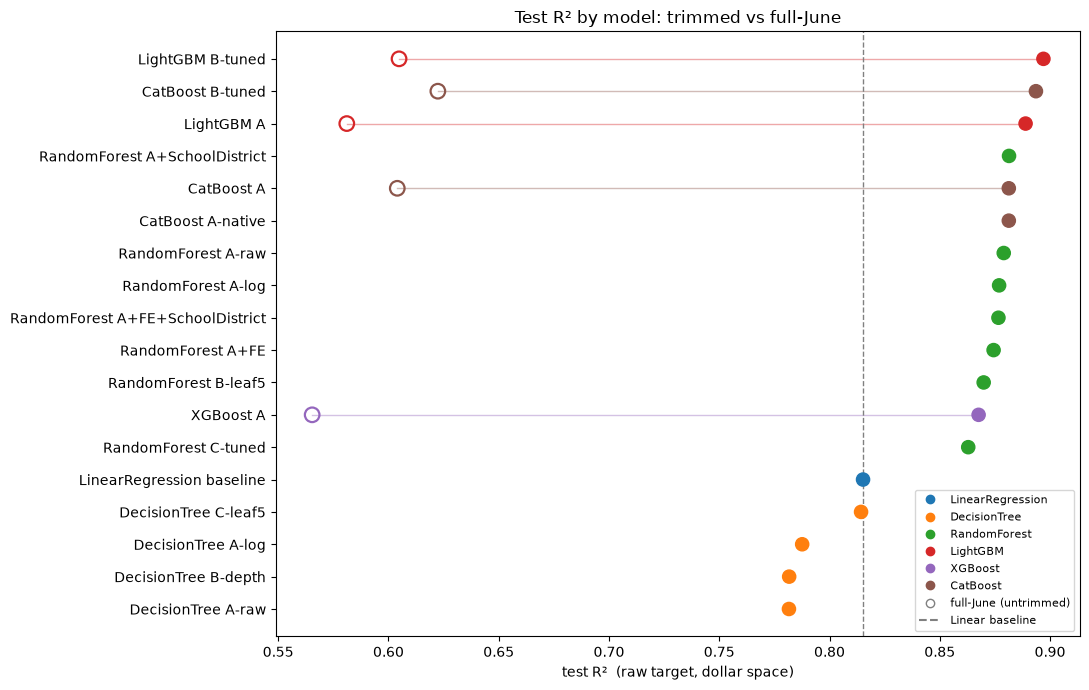

In [36]:
# Visualize the results across ALL models now
# LGBM and XGB both have the untrimmed test R^2 as noted by the hollow dots in plot

# untrimmed = {
#     "LightGBM|A": 0.5811,
#     "LightGBM|B-tuned": 0.6048,
#     "XGBoost|A": 0.5654,
# }

# untrimmed_results = {}

# for key, var in untrimmed.items():
#     if var in globals():
#         pred = globals()[var]["model"].predict(test_df_full[feature])
#         untrimmed_results[key] = round(r2_score(test_df_full[TARGET], pred), 4)

d = pd.read_csv(RESULTS)
d["key"] = d["model"] + "|" + d["version"]
d = d.sort_values("test_r2").reset_index(drop=True)

# unknown = [k for k in untrimmed_results if k not in set(d["key"])]
# assert not unknown, f"untrimmed keys not in results log: {unknown}"
# print(f"computed untrimmed for {len(untrimmed_results)} model(s): {untrimmed_results}")


fam_color = {"LinearRegression": "tab:blue", "DecisionTree": "tab:orange",
             "RandomForest": "tab:green", "LightGBM": "tab:red", "XGBoost": "tab:purple",
             "CatBoost": "tab:brown", "Ensemble": "black"}
colors = d["model"].map(fam_color).fillna("gray")

fig, ax = plt.subplots(figsize=(11, 7))
y = range(len(d))
ax.scatter(d["test_r2"], y, c=colors, s=90, zorder=3)

# overlay full-June where known
for yi, k in zip(y, d["key"]):
    if k in full_june:
        ax.scatter(full_june[k], yi, facecolors="none", edgecolors=colors.iloc[yi],
                   s=110, linewidths=1.6, zorder=3)
        ax.plot([full_june[k], d["test_r2"].iloc[yi]], [yi, yi],
                color=colors.iloc[yi], lw=1, alpha=0.4, zorder=2)

ax.axvline(0.8152, ls="--", color="gray", lw=1)
ax.set_yticks(list(y))
ax.set_yticklabels([f'{m} {v}' for m, v in zip(d["model"], d["version"])])
ax.set_xlabel("test R²  (raw target, dollar space)")
ax.set_title(f"Test R² by model: trimmed vs full-June")

handles = [plt.Line2D([0],[0], marker='o', ls='', color=c, label=f) for f,c in fam_color.items() if f in set(d["model"])]
handles.append(plt.Line2D([0],[0], marker='o', ls='', mfc='none', mec='gray', label='full-June (untrimmed)'))
handles.append(plt.Line2D([0],[0], ls='--', color='gray', label='Linear baseline'))
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## Feature Engineering + District (from week 6)\

- featuring just LightGBM and CatBoost since XGB was found inefficient 
- Each model does use a different representation:
    - LGBM: one-hot feature sets
    - CB: raw categoricals
    - Models will be compared by the deltas for clear comparison

In [32]:
og = [c for c in df.columns if c not in EXCLUDE and not c.startswith("District_")]
district_cols = [c for c in df.columns if c.startswith("District_")]
engineered = [c for c in["BedBathRatio", "PropertyAge", "LotToLiving_log",
              "LivingAreaPerBedroom", "HasGarage", "AmenityCount"] if c in df.columns]

lgbm_cfg = dict(**gb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
# xgb_cfg  = dict(**xgb_search.best_params_, tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)

onehot_pref  = ("Zip_", "City_", "County_", "District_")
structural   = [c for c in feature if not c.startswith(onehot_pref)]
loc_cats     = [c for c in ["City", "PostalCode", "CountyOrParish"] if c in df.columns]
district_cat = [c for c in ["SchoolDistrict"] if c in df.columns]

sets = {
    "Original":              og,
    "+engineered":           og + engineered,
    "+district":             og + district_cols,
    "+engineered+district":  og + engineered + district_cols,
}

cb_sets = {"Original":              (structural + loc_cats,                            loc_cats),
           "+engineered":           (structural + loc_cats + engineered,               loc_cats),
           "+district":             (structural + loc_cats + district_cat,             loc_cats + district_cat),
           "+engineered+district":  (structural + loc_cats + engineered + district_cat, loc_cats + district_cat)}

CB_ITERS = 800   # held fixed for a fast ablation
cb_cfg   = cat_best_params if "cat_best_params" in globals() else {"depth": 6, "learning_rate": 0.05}

def cat_frame(frame, feats, cats):
    X = frame[feats].copy()
    for c in cats:
        X[c] = frame[c].astype("string").fillna("Unknown").astype(str)
    return X

def run_cat(feats, cats):
    m = CatBoostRegressor(iterations=CB_ITERS, cat_features=cats, max_ctr_complexity=1,
                          random_state=RANDOM_STATE, thread_count=-1, verbose=False, **cb_cfg)
    m.fit(cat_frame(train_df, feats, cats), y_train)
    return r2_score(y_test, m.predict(cat_frame(test_df, feats, cats)))

rows = []
for name in ["Original", "+engineered", "+district", "+engineered+district"]:
    lgf = sets[name]
    # xg = fit_eval(XGBRegressor(**xgb_cfg),  use_log=False, X_tr=train_df[feats], X_te=test_df[feats])
    cbf, cbc = cb_sets[name]
    lg = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False, X_tr=train_df[lgf], X_te=test_df[lgf])

    rows.append({"feature_set": name, 
                 "LGBM_nfeat": len(lgf),
                 "LightGBM": round(lg["test_r2"], 4),
                # "XGBoost": round(xg["test_r2"], 4)
                 "CatBoost_nfeat": len(cbf), 
                 "CatBoost": round(run_cat(cbf, cbc), 4)
                })

gbm_fe = pd.DataFrame(rows)
print(gbm_fe.to_string(index=False))

         feature_set  LGBM_nfeat  LightGBM  CatBoost_nfeat  CatBoost
            Original        1185    0.8970              21    0.8824
         +engineered        1191    0.8967              27    0.8831
           +district        1547    0.8989              22    0.8846
+engineered+district        1553    0.8977              28    0.8841


### Interpret
Note: commented out xgb since the model takes too long to run and is inefficient

- best config for both LGBM and CB was the base + SchoolDistrict addition

# Individual engineered features + district

In [38]:
base = og + district_cols          # district base, matching the RF individual ablation
cb_base_feats, cb_base_cats = structural + loc_cats + district_cat, loc_cats + district_cat  # CatBoost

def run_lgbm(feats):
    r = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False,
                 X_tr=train_df[feats], X_te=test_df[feats])
    return r["test_r2"]

# sets = {"+district (base)": base}
# for f in engineered:
#     sets[f"+district +{f}"] = base + [f]
# sets["+district +all eng"] = base + engineered

rows = [{"feature_set": "+district (base)", 
        #  "n_features": len(feats), 
         "LightGBM": round(run_lgbm(base), 4),
         "CatBoost": round(run_cat(cb_base_feats, cb_base_cats), 4)}]

for f in engineered:
    rows.append({"feature_set": f"+district +{f}",
                 "LightGBM": round(run_lgbm(base + [f]), 4),
                 "CatBoost": round(run_cat(cb_base_feats + [f], cb_base_cats), 4)})
rows.append({"feature_set": "+district +all eng", 
             "LightGBM": round(run_lgbm(base + engineered), 4), 
             "CatBoost": round(run_cat(cb_base_feats + engineered, cb_base_cats), 4)})


lgbm_indiv = pd.DataFrame(rows)
print(lgbm_indiv.to_string(index=False))

                    feature_set  LightGBM  CatBoost
               +district (base)    0.8989    0.8846
        +district +BedBathRatio    0.8982    0.8844
         +district +PropertyAge    0.8995    0.8853
     +district +LotToLiving_log    0.8977    0.8846
+district +LivingAreaPerBedroom    0.9007    0.8838
           +district +HasGarage    0.8989    0.8842
        +district +AmenityCount    0.8991    0.8830
             +district +all eng    0.8977    0.8841


### Interpret:

+district +LivingAreaPerBedroom        1548    0.9007

My original assumption was that LightGBM would perform best with just the addition of SchoolDistrict (like RF did), since already the engineered features had a similar effect in reducing the R^2 result when added to LightGBM. However, when looking at the individuals, LivingAreaPerBedroom and PropertyAge each boost the R^2 when seperately added to SchoolDistrict. 

This leads to my next check: would PropertyAge + LivingAreaPerBedroom + district win over district + LivingAreaPerBedroom (0.9007), potentially could optimize the June test set.

- adding in CatBoost:
    - Only recieves a slight increase from +district +PropertyAge
    - Unlight LGBM, living area per bedroom worsens CatBoost
    - Generally similar results, engineered features don't make a significant change

### side experiment: does adding PropertyAge + LivingAreaPerBedroom improve LightGBM?

`LivingAreaPerBedroom` (+0.0018) and `PropertyAge` (+0.0006) were the only engineered features to individually increase LightGBM

In [22]:
combo = og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"]
r = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False, X_tr=train_df[combo], X_te=test_df[combo])
full = r2_score(test_df_full[TARGET], r["model"].predict(test_df_full[combo])) #untrimmed check as well
print(f"+district +PropertyAge +LivingAreaPerBedroom =")
print(f"  trimmed: {r['test_r2']:.4f}  \n"
      "          (base LGBM = 0.8989, base+district+LivingAreaPerBedroom = 0.9007)")
print(f"  full-June  : {full:.4f}")

+district +PropertyAge +LivingAreaPerBedroom =
  trimmed: 0.9000  
          (base LGBM = 0.8989, base+district+LivingAreaPerBedroom = 0.9007)
  full-June  : 0.6103


In [23]:
# Cross validation checks for the combo vs base feature sets

order = np.argsort(train_df[DATE].to_numpy())
base_feats  = og + district_cols
combo_feats = og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"]
y_sorted = train_df.iloc[order][TARGET].reset_index(drop=True)

for label, feats in [("+district (base)", base_feats),
                     ("+district +PropertyAge +LivingAreaPerBedroom", combo_feats)]:
    X_sorted = train_df.iloc[order][feats].reset_index(drop=True)
    scores = cross_val_score(LGBMRegressor(**lgbm_cfg), X_sorted, y_sorted,
                             cv=monthly_splits, scoring="r2", n_jobs=-1)
    folds = "  ".join(f"{s:.3f}" for s in scores)
    print(f"{label:30} mean {scores.mean():.4f}  |  folds: {folds}")

+district (base)               mean 0.8950  |  folds: 0.889  0.895  0.897  0.899
+district +PropertyAge +LivingAreaPerBedroom mean 0.8945  |  folds: 0.891  0.893  0.896  0.899


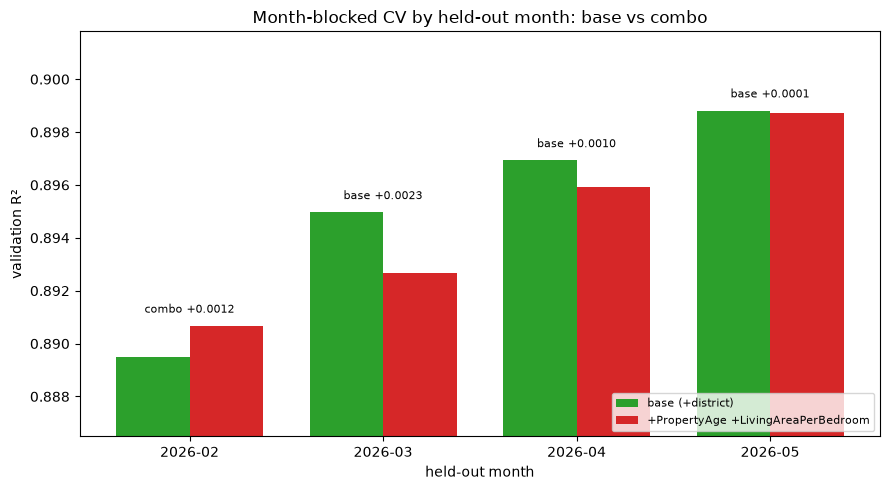

In [24]:
# Per-month visualization of the district only vs combo feature sets

order = np.argsort(train_df[DATE].to_numpy())
per_sorted = train_df.iloc[order][DATE].dt.to_period("M").reset_index(drop=True)
val_months = [str(m) for m in sorted(per_sorted.unique())[-4:]]

def per_month_scores(feats):
    Xs = train_df.iloc[order][feats].reset_index(drop=True)
    ys = train_df.iloc[order][TARGET].reset_index(drop=True)
    return np.array([
        r2_score(ys.iloc[va],
                 LGBMRegressor(**lgbm_cfg).fit(Xs.iloc[tr], ys.iloc[tr]).predict(Xs.iloc[va]))
        for tr, va in monthly_splits
    ])

base_s  = per_month_scores(og + district_cols)
combo_s = per_month_scores(og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(val_months)); w = 0.38
ax.bar(x - w/2, base_s,  w, label="base (+district)",    color="tab:green")
ax.bar(x + w/2, combo_s, w, label="+PropertyAge +LivingAreaPerBedroom", color="tab:red")

for xi, (b, c) in enumerate(zip(base_s, combo_s)):
    winner = "base" if b >= c else "combo"
    ax.text(xi, max(b, c) + 0.0005, f"{winner} +{abs(b - c):.4f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(val_months)
lo = min(base_s.min(), combo_s.min()); hi = max(base_s.max(), combo_s.max())
ax.set_ylim(lo - 0.003, hi + 0.003)   # zoom into the noise band so per-month gaps are visible
ax.set_ylabel("validation R²"); ax.set_xlabel("held-out month")
ax.set_title("Month-blocked CV by held-out month: base vs combo")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


### Interpret:

- Combining the individually stronger feature engineerings with the base and school district of LightGBM didn't make the result any stronger than the base + school district + LivingArea per Bedroom. 

- validated it with month-blocked cross-validation on the training months only
- cross-validation show base (+district) is better and wins or ties in every month of the folding (showing the noise floor)

- Best LightGBM for modelling the dataframe is the base + SchoolDistrict

## Final Model Summary

Best models: `LightGBM B-tuned` and `CatBoost B-tuned`

- LightGBM B-tuned (trimmed) R^2 = 0.8970  (train 0.9501, gap 0.0531)
    - full-June R^2 = 0.6048

- CatBoost B-tuned (trimmed) R^2 = 0.8936 (train 0.9211, gap 0.0274)
    - full-June R² = 0.6224

- Baseline: R^2 = 0.8152

CatBoost is technically the better model than LightGBM tuned because not only does it perform more accurately on the full-june (untrimmed set), it also shows half the overfitting gap that LightGBM does.

Final Ranking:
- CatBoost = LightGBM Gradient boosting > Random Forest > Linear > Decision Tree, on both accuracy and train/test gap


# Findings across the models

Geography (school district on top of ZIP/City):
  - RF:       +0.002   (redundant; lat-long + ZIP/City already encode location)
  - LightGBM: +0.002   ( redundant for boosting too)
  - CatBoost: +0.002   (native SchoolDistrict, not one-hot)

- District adds such a small difference to any tree model, Zip and City make the most difference

Engineered ratios (Bed/Bath, Age, Lot/Living, LivAreaPerBed, HasGarage, AmenityCount):
  - Linear:   +0.015   (helps significantly, linear can't build interactions itself)
  - RF:       no or worse effect
  - LightGBM: LivingAreaPerBedroom +0.0018 but not consistently in the untrimmed version
  - CatBoost: only PropertyAge nudges up (+0.0007), within noise

- Engineered features help Linear, are neutral/noisy for tree ensembles.

Model ranking (trimmed contract / honest full-June):
  - CatBoost B-tuned : 0.894 / 0.622   (least overfit, best tail)
  - LightGBM B-tuned : 0.897 / 0.605
  - RandomForest   : 0.870 / 0.552
  - Linear baseline  : 0.815 / 0.523

Note: markdown of earlier files need updating since dataframe expanded, and implemented 1/99 trim, interpretation cells are now outdated
- XGBoost matches LightGBM's range but is extremely slow, so LGBM takes lead anyway


# Post Team meeting update:

- integrating CatBoost

New Findings:
 
- CatBoost tuned (B) is as strong as LightGBM tuned (B), with a 0.004 difference
    - Looking at the untrimmed test set of June reveals that CatBoost is +0.02 stronger in accuracy (0.6224 vs 0.6048)